In [1]:
import os 
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']
ALGS = ['RDSGD', 'ORACLE_0', 'ORACLE_1', 'IOS', 'SCC', 'TriMean', 'CooMed']

exp_name = 'data-het'
graph = 'random-regular'

In [14]:
RUN_DIR = Path().resolve()
d = os.path.join(RUN_DIR, exp_name, graph)
assert len(os.listdir(d)) > 0, print(os.listdir(d))

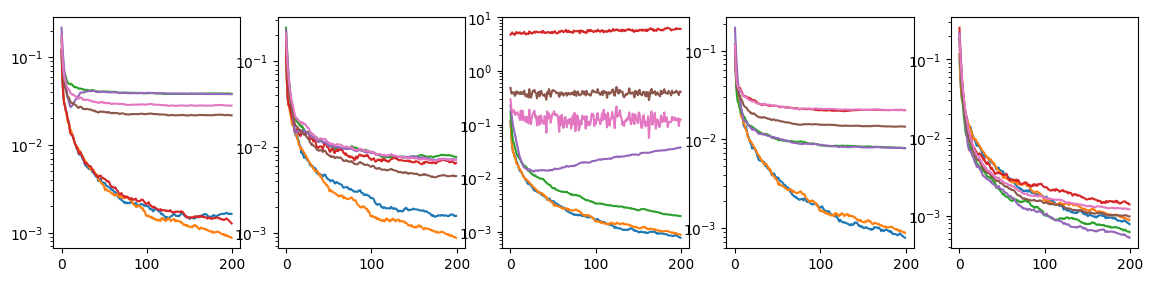

In [15]:
fig, ax = plt.subplots(1,5,figsize=(14,3))
for atk_idx, atk in enumerate(ATKS):
    csv_fname = os.path.join(RUN_DIR,exp_name,graph,f'sys_sim_df_{graph}_5_{atk}.csv')
    df = pd.read_csv(csv_fname).set_index('alg')
    for alg in ALGS:
        V = df.loc[alg, 'C_unif'] + np.pow(df.loc[alg, 'opt_gap'], 2)
        ax[atk_idx].plot(np.arange(200),V[:200])
        ax[atk_idx].set(yscale='log')

In [49]:
algos = ['CooMed', 'IOS', 'ORACLE_0', 'ORACLE_1', 'RDSGD', 'SCC', 'TriMean']
columns = ['graph', 'attack'] + [f'mean_{a}' for a in algos] + [f'std_{a}' for a in algos]

df1 = pd.read_csv(os.path.join(RUN_DIR,'data-het','test_accuracy.csv'), sep=',', skiprows=3, header=None, names=columns)
df1 = df1.set_index(['graph', 'attack'])

In [50]:
df1

mean_CooMed  mean_IOS  mean_ORACLE_0  \
graph           attack                                             
barabasi-albert ALIE           0.848078  0.845429       0.851039   
                IPM            0.849489  0.844814       0.851039   
                gaussian       0.650537  0.507299       0.851039   
                label_flip     0.845671  0.847013       0.851039   
                sign_flip      0.831965  0.833810       0.851039   
erdos-renyi     ALIE           0.849368  0.848121       0.850978   
                IPM            0.850113  0.847896       0.850978   
                gaussian       0.848061  0.258615       0.850978   
                label_flip     0.845835  0.848571       0.850978   
                sign_flip      0.833186  0.832139       0.850978   
geometric       ALIE           0.848753  0.848260       0.850571   
                IPM            0.849974  0.848017       0.850571   
                gaussian       0.845688  0.494130       0.850571   
                label_flip     0.845186  0.849169       0.850571   
                sign_flip      0.831922  0.831143       0.850571   
random-regular  ALIE           0.849195  0.846675       0.850597   
                IPM            0.850043  0.847048       0.850597   
                gaussian       0.840398  0.411671       0.850597   
                label_flip     0.845610  0.848675       0.850597   
                sign_flip      0.834294  0.835368       0.850597   
watts-strogatz  ALIE           0.849429  0.848225       0.850658   
                IPM            0.850416  0.849567       0.850658   
                gaussian       0.549645  0.390996       0.850658   
                label_flip     0.845446  0.847074       0.850658   
                sign_flip      0.834589  0.839411       0.850658   

                            mean_ORACLE_1  mean_RDSGD  mean_SCC  mean_TriMean  \
graph           attack                                                          
barabasi-albert ALIE             0.850857    0.848528  0.849922      0.848658   
                IPM              0.851385    0.849203  0.851056      0.850416   
                gaussian         0.850286    0.850381  0.832831      0.317316   
                label_flip       0.844087    0.850234  0.842571      0.845636   
                sign_flip        0.833030    0.836234  0.832182      0.834563   
erdos-renyi     ALIE             0.850675    0.850571  0.850199      0.849541   
                IPM              0.850944    0.850563  0.850814      0.850026   
                gaussian         0.849688    0.850329  0.831723      0.572294   
                label_flip       0.843550    0.850450  0.842433      0.846095   
                sign_flip        0.833801    0.846035  0.833455      0.836502   
geometric       ALIE             0.850615    0.850563  0.850312      0.849004   
                IPM              0.850745    0.850390  0.850805      0.850095   
                gaussian         0.849983    0.850260  0.831706      0.730017   
                label_flip       0.843368    0.850251  0.842303      0.845610   
                sign_flip        0.833550    0.843766  0.833420      0.834701   
random-regular  ALIE             0.850407    0.850424  0.850355      0.849368   
                IPM              0.850727    0.850450  0.850623      0.850242   
                gaussian         0.849584    0.850294  0.830840      0.755377   
                label_flip       0.843195    0.849983  0.842234      0.846589   
                sign_flip        0.834355    0.845801  0.834087      0.838909   
watts-strogatz  ALIE             0.850701    0.850416  0.850190      0.849429   
                IPM              0.850978    0.850424  0.850883      0.850294   
                gaussian         0.849853    0.850459  0.831411      0.583844   
                label_flip       0.843913    0.850459  0.842329      0.846918   
                sign_flip        0.833706    0.844952  0.833541      0.840823   

   